# YOLO on PC Chapter 11 Workshop 5

## Load module

In [1]:
import torch

In [2]:
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"{torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'No CUDA device available'}")

PyTorch version: 2.7.1+cpu
CUDA available: False
No CUDA device available


## Load model

### Load model from github repository 

In [ ]:
# load from github repository 
model = torch.hub.load('ultralytics/yolov5', 'yolov5s', pretrained=True)


### Load model from local path

In [ ]:
model_path = "./model/yolov5s.pt"
model = torch.hub.load('ultralytics/yolov5', 'custom', path=model_path, source='local')


## Evaluate model

In [ ]:
model.eval()  # Set the model to evaluation mode

## Save model

In [46]:
# model.save('yolov5s.pt')  # Save the model to a file
# torch.save(model.state_dict(),'../models/yolov5s/yolov5s_state_dict.pt')

## Declare image uri

In [51]:
img_url = 'https://ultralytics.com/images/bus.jpg'
## img_url = ['https://web.com/bus.jpg', 'https://web.com/images2.jpg']
## img_url = Image.open('filename.jpg')


## Use model

In [ ]:
results = model(img_url)  # inference
results.print()  # print results

## Show model result

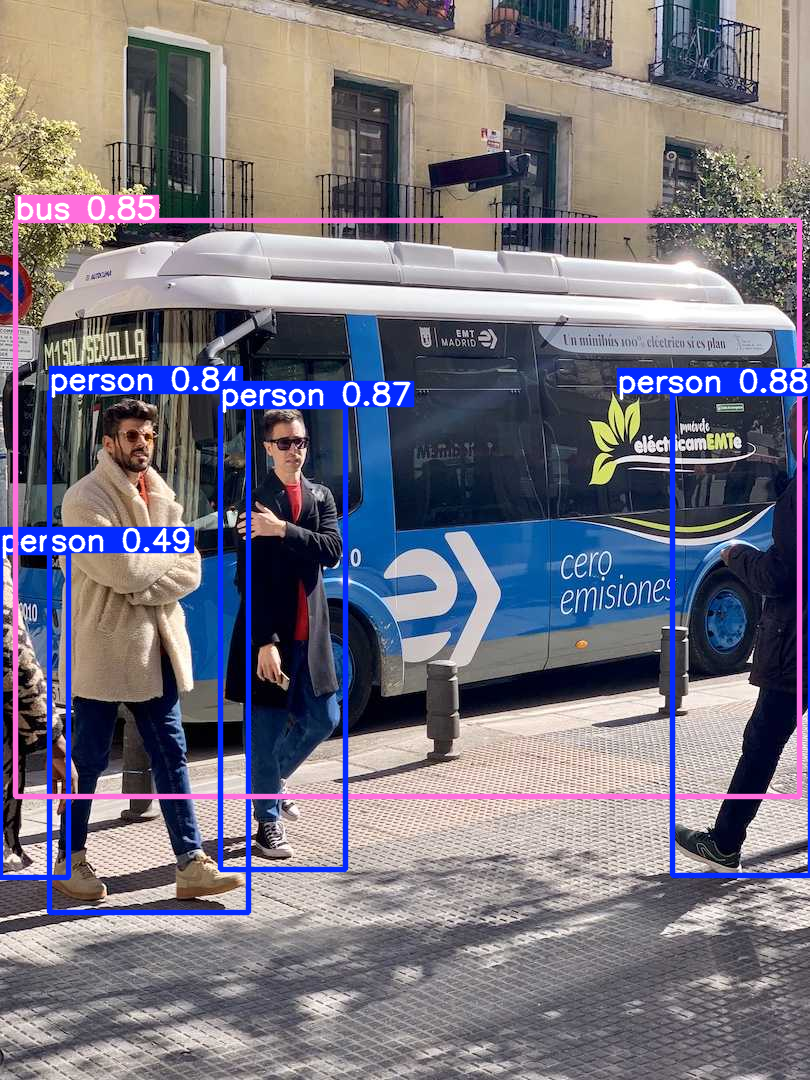

In [6]:
results.show()  # display results

## Own drawing from results

### load module

In [21]:
from  urllib.request import urlopen   # load module for requesing data     
from PIL import Image, ImageFont, ImageDraw
from matplotlib.pyplot import imshow
import os
import matplotlib.pyplot as plt
import numpy as np

### load image

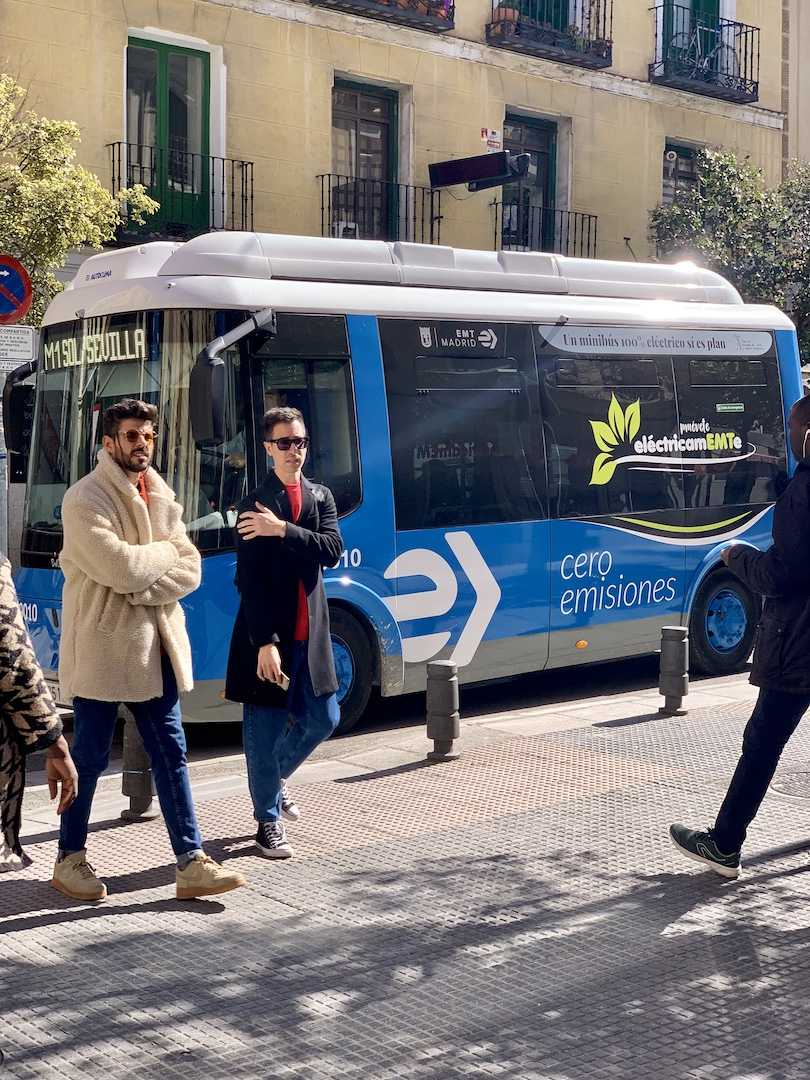

In [40]:
img = Image.open(urlopen(img_url))
img


### Draw rectangle

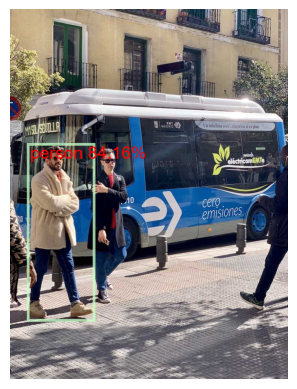

In [41]:
%matplotlib inline
i = 3
# ค่าพิกัด Coordinate จุดทแยง 2 จุด (ตีกรอบวัตถุ)
p1 = (results.pandas().xyxy[0][i:i+1].xmin, results.pandas().xyxy[0][i:i+1].ymin)
p2 = (results.pandas().xyxy[0][i:i+1].xmax, results.pandas().xyxy[0][i:i+1].ymax)

draw = ImageDraw.Draw(img, "RGBA") # เตรียมเขียนทับภาพ (Overlay)
draw.rectangle((p1,p2), outline=(200,255,200,200), width=8) # draw rectangle

# font_path = os.path.abspath('Humor-Sans.ttf')
font = ImageFont.truetype('arial.ttf', 50) # set font
# font = ImageFont.load_default()
conf = results.pandas().xyxy[0][i:i+1].confidence[i] # confident value
conf_txt = f" {round(conf*100, 2)}%"
label = results.pandas().xyxy[0][i:i+1].name[i] + conf_txt  # label on retangle boundary
draw.text((p1[0]+10,p1[1]), label, fill=(255,0,0),font=font, align="left") # draw label

plt.imshow(img)
plt.axis('off')  # Hide axes
plt.show()  # Show the image with the bounding box